In [185]:
!pip install category_encoders

In [186]:
!pip install catboost

In [187]:
!pip install xgboost

In [188]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional, List

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import category_encoders as ce

import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import xgboost as xgb

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

### 1. Download data from Don’tGetKicked competition.Design train/validation/test split.

In [189]:
data = pd.read_csv("training.csv")
data['PurchDate'] = pd.to_datetime(data['PurchDate'], errors='coerce')
data.sort_values('PurchDate', inplace=True)
data.reset_index(drop=True, inplace=True)

In [190]:
num = len(data) // 3
X_train = data.iloc[:num].copy()
X_val   = data.iloc[num:2*num].copy()
X_test  = data.iloc[2*num:].copy()

assert X_train['PurchDate'].max() <= X_val['PurchDate'].min(), \
    "Пересечение дат train/val!"
assert X_val['PurchDate'].max() <= X_test['PurchDate'].min(), \
    "Пересечение дат val/test!"

print(f"train: {X_train.shape} | {X_train['PurchDate'].min().date()} → {X_train['PurchDate'].max().date()}")
print(f"val:   {X_val.shape}   | {X_val['PurchDate'].min().date()} → {X_val['PurchDate'].max().date()}")
print(f"test:  {X_test.shape}  | {X_test['PurchDate'].min().date()} → {X_test['PurchDate'].max().date()}")

train: (24327, 34) | 2009-01-05 → 2009-09-15
val:   (24327, 34)   | 2009-09-15 → 2010-05-14
test:  (24329, 34)  | 2010-05-14 → 2010-12-30


In [191]:
na_rate = X_train.isnull().mean()
cols_to_drop = na_rate[na_rate > 0.5].index.tolist()

print(f"\n>50% пропусков: {cols_to_drop}")

X_train = X_train.drop(columns=cols_to_drop)
X_val  = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)


>50% пропусков: ['PRIMEUNIT', 'AUCGUART']


In [192]:
def extract_date_features(df):
    df = df.copy()
    df['purchase_day']   = df['PurchDate'].dt.day
    df['purchase_month'] = df['PurchDate'].dt.month
    df['purchase_year']  = df['PurchDate'].dt.year
    df = df.drop(columns=['PurchDate'])
    return df

X_train = extract_date_features(X_train)
X_val   = extract_date_features(X_val)
X_test  = extract_date_features(X_test)

In [193]:
id_cols = ['RefId', 'WheelTypeID']
train_raw = X_train.drop(columns=id_cols, errors='ignore')
val_raw   = X_val.drop(columns=id_cols, errors='ignore')
test_raw  = X_test.drop(columns=id_cols, errors='ignore')

In [194]:
TARGET = 'IsBadBuy'

y_train = train_raw[TARGET].values
X_train = train_raw.drop(columns=[TARGET])

y_val   = val_raw[TARGET].values
X_val   = val_raw.drop(columns=[TARGET])

y_test  = test_raw[TARGET].values
X_test  = test_raw.drop(columns=[TARGET])

In [195]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
n_unique = X_train[cat_features].nunique()

low_card  = n_unique[n_unique <= 10].index.tolist()  
mid_card  = n_unique[(n_unique > 10) & (n_unique <= 50)].index.tolist()  
high_card = n_unique[n_unique > 50].index.tolist()   

print(f"\nЧисловых признаков:           {len(numeric_features)}")
print(f"Категориальных low_card:      {len(low_card)}  {low_card}")
print(f"Категориальных mid_card:      {len(mid_card)}  {mid_card}")
print(f"Категориальных high_card:     {len(high_card)} {high_card}")


Числовых признаков:           19
Категориальных low_card:      5  ['Auction', 'Transmission', 'WheelType', 'Nationality', 'TopThreeAmericanName']
Категориальных mid_card:      4  ['Make', 'Color', 'Size', 'VNST']
Категориальных high_card:     3 ['Model', 'Trim', 'SubModel']


In [196]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

low_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first',           
    )),
])

mid_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])

high_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', ce.CatBoostEncoder(
        handle_unknown='value',   
        handle_missing='value',
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',       numeric_pipeline,  numeric_features),
        ('low_card',  low_card_pipeline, low_card),
        ('mid_card',  mid_card_pipeline, mid_card),
        ('high_card', high_card_pipeline, high_card),
    ],
    remainder='drop',    
    verbose_feature_names_out=False,
)

In [197]:
preprocessor.fit(X_train, y_train)
X_train_new = preprocessor.transform(X_train)
X_valid_new = preprocessor.transform(X_val)
X_test_new = preprocessor.transform(X_test)

In [198]:
def gini_score(y_true, y_pred):
    """
    Вычисляет Gini коэффициент.

    y_true : массив 0/1 (правильные метки)
    y_pred : массив вероятностей предсказания класса 1

    Возвращает:
    gini : float
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    order = np.argsort(-y_pred)
    y_true_sorted = y_true[order]

    n_pos = np.sum(y_true_sorted)
    n_neg = len(y_true_sorted) - n_pos

    if n_pos == 0 or n_neg == 0:
        return 0 

    cum_pos = np.cumsum(y_true_sorted)
    total_pos_rank = np.sum(cum_pos[y_true_sorted==0]) 

    auc = total_pos_rank / (n_pos * n_neg)

    gini = 2 * auc - 1
    return gini

### 2. Create a Python class for Decision Tree Classifier and Decision Tree Regressor (MSE loss).

In [199]:
@dataclass
class Node:
    """
    Узел дерева решений.
    
    Дерево — это структура из узлов:
    - Внутренний узел (не лист): хранит условие сплита (feature, threshold)
      и указатели на двух детей (left, right)
    - Лист (leaf): хранит предсказание (value, class_distribution)
    
    """

    feature: Optional[int] = None     
    threshold: Optional[float] = None  
    
    left: Optional['Node'] = None   
    right: Optional['Node'] = None 
    
    value: Optional[float] = None                    
    class_distribution: Optional[np.ndarray] = None 
    gain: Optional[float] = None                     
    
    @staticmethod
    def gini_impurity(y: np.ndarray, n_classes: int) -> float:
       
        if len(y) == 0:
            return 0.0
        counts = np.bincount(y, minlength=n_classes) 
        probs = counts / len(y)
        return 1.0 - np.sum(probs ** 2)
    
    @staticmethod
    def variance(y: np.ndarray) -> float:
        """MSE criterion для регрессии: насколько значения разбросаны вокруг среднего"""
        if len(y) == 0:
            return 0.0
        return np.var(y)


Decision Tree Classifier
    
Алгоритм обучения (fit):
1. Начинаем с корневого узла (все данные)
2. Для каждого узла ищем лучший сплит (best_split)
3. Делим данные на левую (≤ threshold) и правую (> threshold) части
4. Рекурсивно повторяем для каждой части
5. Останавливаемся когда: достигли max_depth, данных стало мало, или нет выигрыша
    
Алгоритм предсказания (predict_proba):
1. Для каждого объекта спускаемся по дереву
2. В каждом узле: если X[feature] <= threshold → влево, иначе → вправо
3. В листе возвращаем распределение классов

In [200]:
@dataclass
class MyDecisionTreeClassifier:
    
    max_depth: Optional[int] = None  
    min_samples_split: int = 2      
    min_samples_leaf: int = 1        
    random_state: int = 42
    
    root: Optional[Node] = None
    n_classes_: int = 0
    
    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)
    
    def _gini(self, y: np.ndarray) -> float:
        return Node.gini_impurity(y, self.n_classes_)
    
    def _class_probs(self, y: np.ndarray) -> np.ndarray:
        counts = np.bincount(y, minlength=self.n_classes_)
        return counts / len(y)
    
    def best_split(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        best_feature, best_threshold, best_gain = None, None, -1.0
        
        parent_gini = self._gini(y)
        
        for feat_idx in range(n_features):
            thresholds = np.unique(X[:, feat_idx])
            
            for threshold in thresholds:
                left_mask = X[:, feat_idx] <= threshold
                right_mask = ~left_mask
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                if (len(y_left) < self.min_samples_leaf or 
                    len(y_right) < self.min_samples_leaf):
                    continue
                
                # Information Gain
                p_left = len(y_left) / n_samples
                gain = (parent_gini 
                        - p_left * self._gini(y_left)
                        - (1 - p_left) * self._gini(y_right))
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feat_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X: np.ndarray, y: np.ndarray, depth: int = 0) -> Node:
        probs = self._class_probs(y)
        majority_class = int(np.argmax(probs)) 
        
        is_pure = len(np.unique(y)) == 1
        too_small = len(y) < self.min_samples_split
        max_depth_reached = (self.max_depth is not None and depth >= self.max_depth)
        
        if is_pure or too_small or max_depth_reached:
            return Node(value=majority_class, class_distribution=probs)
        
        feature, threshold, gain = self.best_split(X, y)
        
        if feature is None or gain <= 0:
            return Node(value=majority_class, class_distribution=probs)
        
        left_mask = X[:, feature] <= threshold
        
        return Node(
            feature=feature,
            threshold=threshold,
            gain=gain,
            class_distribution=probs,
            
            left=self._build_tree(X[left_mask], y[left_mask], depth + 1),
            right=self._build_tree(X[~left_mask], y[~left_mask], depth + 1),
        )
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=int)
        
        self.n_classes_ = len(np.unique(y))  
        self.root = self._build_tree(X, y)   
        return self
    
    def _predict_one(self, x: np.ndarray, node: Node) -> np.ndarray:
        """
        Спускается по дереву для одного объекта x.
        Возвращает вектор вероятностей из листа.
        """
        if node.value is not None:
            return node.class_distribution
        
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)
    
    def predict_proba(self, X) -> np.ndarray:
        """Возвращает вероятности классов для каждого объекта"""
        X = np.asarray(X, dtype=np.float64)
        return np.array([self._predict_one(x, self.root) for x in X])
    
    def predict(self, X) -> np.ndarray:
        """Возвращает предсказанный класс"""
        return np.argmax(self.predict_proba(X), axis=1)


Decision Tree Regressor
    
Отличия от классификатора:
   1. Критерий: дисперсия (variance) вместо Gini
       - Ищем сплит, который минимизирует дисперсию в дочерних узлах
       - В листе возвращаем среднее значение (а не класс большинства)
   2. Нужен для GBDT — там регрессор предсказывает остатки (residuals)
    
Оптимизация скорости:
   Вместо перебора всех уникальных значений (как в классификаторе),
   используем n_percentiles=50 квантилей. Это быстрее
   и почти не теряет в качестве.


In [201]:
@dataclass
class MyDecisionTreeRegressor:
    
    max_depth: Optional[int] = None
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    n_percentiles: int = 50 
    random_state: int = 42
    
    root: Optional[Node] = None
    
    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)
    
    def best_split(self, X: np.ndarray, y: np.ndarray):
        """Ищет лучший сплит по критерию уменьшения дисперсии"""
        n_samples, n_features = X.shape
        best_feature, best_threshold, best_gain = None, None, -1.0
        
        parent_var = Node.variance(y)
        
        if parent_var < 1e-12:
            return best_feature, best_threshold, best_gain
        
        for feat_idx in range(n_features):
            feat_vals = X[:, feat_idx]
            
            percentiles = np.linspace(10, 90, self.n_percentiles)
            thresholds = np.unique(np.percentile(feat_vals, percentiles))
            
            for threshold in thresholds:
                left_mask = feat_vals <= threshold
                right_mask = ~left_mask
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                if (len(y_left) < self.min_samples_leaf or 
                    len(y_right) < self.min_samples_leaf):
                    continue
                
                p_left = len(y_left) / n_samples
                variance_reduction = (parent_var 
                                      - p_left * Node.variance(y_left)
                                      - (1 - p_left) * Node.variance(y_right))
                
                if variance_reduction > best_gain:
                    best_gain = variance_reduction
                    best_feature = feat_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X: np.ndarray, y: np.ndarray, depth: int = 0) -> Node:
        mean_val = float(np.mean(y)) 
        
        too_small = len(y) < self.min_samples_split
        max_depth_reached = (self.max_depth is not None and depth >= self.max_depth)
        all_same = len(np.unique(y)) == 1
        
        if too_small or max_depth_reached or all_same:
            return Node(value=mean_val, class_distribution=np.array([mean_val]))
        
        feature, threshold, gain = self.best_split(X, y)
        
        if feature is None or gain <= 0:
            return Node(value=mean_val, class_distribution=np.array([mean_val]))
        
        left_mask = X[:, feature] <= threshold
        
        return Node(
            feature=feature,
            threshold=threshold,
            gain=gain,
            class_distribution=np.array([mean_val]),
            left=self._build_tree(X[left_mask], y[left_mask], depth + 1),
            right=self._build_tree(X[~left_mask], y[~left_mask], depth + 1),
        )
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        self.root = self._build_tree(X, y)
        return self
    
    def _predict_one(self, x: np.ndarray) -> float:
        """Спуск по дереву для одного объекта (итеративный, без рекурсии)"""
        node = self.root
        while node.value is None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return float(node.class_distribution[0])
    
    def predict(self, X) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        return np.array([self._predict_one(x) for x in X])

### 3. With your DecisionTree module, you must obtain a Gini score of at least 0.1 on the validation dataset.

In [202]:
tree = MyDecisionTreeClassifier(max_depth=2)
tree.fit(X_train_new, y_train)
y_proba = tree.predict_proba(X_valid_new)
gini = 2 * roc_auc_score(y_val, y_proba[:, 1]) - 1
print(gini)

0.26182851209739


### 4. Use sklearn's DecisionTreeClassifier and check its performance on the validation dataset. Is it better than your module? If so, why?

In [203]:
def gini_score_sk(y_true, y_score):
    return 2 * roc_auc_score(y_true=y_true, y_score=y_score) - 1

best_depth, best_gini = 1, 0

for depth in range(1, 10):
    model = DecisionTreeClassifier(criterion="gini", random_state=42, max_depth=depth)
    model.fit(X=X_train_new, y=y_train)
    y_pred = model.predict_proba(X=X_valid_new)[:, 1]
    gini = gini_score_sk(y_true=y_val, y_score=y_pred) 
    if best_gini < gini:
        best_gini = gini
        best_depth = depth
    print(f"depth={depth}: gini={gini:.4f}")

depth=1: gini=0.2335
depth=2: gini=0.2618
depth=3: gini=0.3214
depth=4: gini=0.3125
depth=5: gini=0.3154
depth=6: gini=0.3219
depth=7: gini=0.2998
depth=8: gini=0.3055
depth=9: gini=0.2713


In [204]:
my_tree = MyDecisionTreeClassifier(max_depth=best_depth)
my_tree.fit(X_train_new, y_train)
y_pred_my = my_tree.predict_proba(X_valid_new)[:, 1]
gini_my = gini_score_sk(y_true=y_val, y_score=y_pred_my)

print(f"Моё дерево:    Gini = {gini_my:.4f}")
print(f"Sklearn дерево: Gini = {best_gini:.4f}")

Моё дерево:    Gini = 0.3224
Sklearn дерево: Gini = 0.3219


Результаты практически одинаковые, разница всего 0.0005 —
это статистически незначимо.

Моё дерево оказалось чуть лучше на этом конкретном датасете.

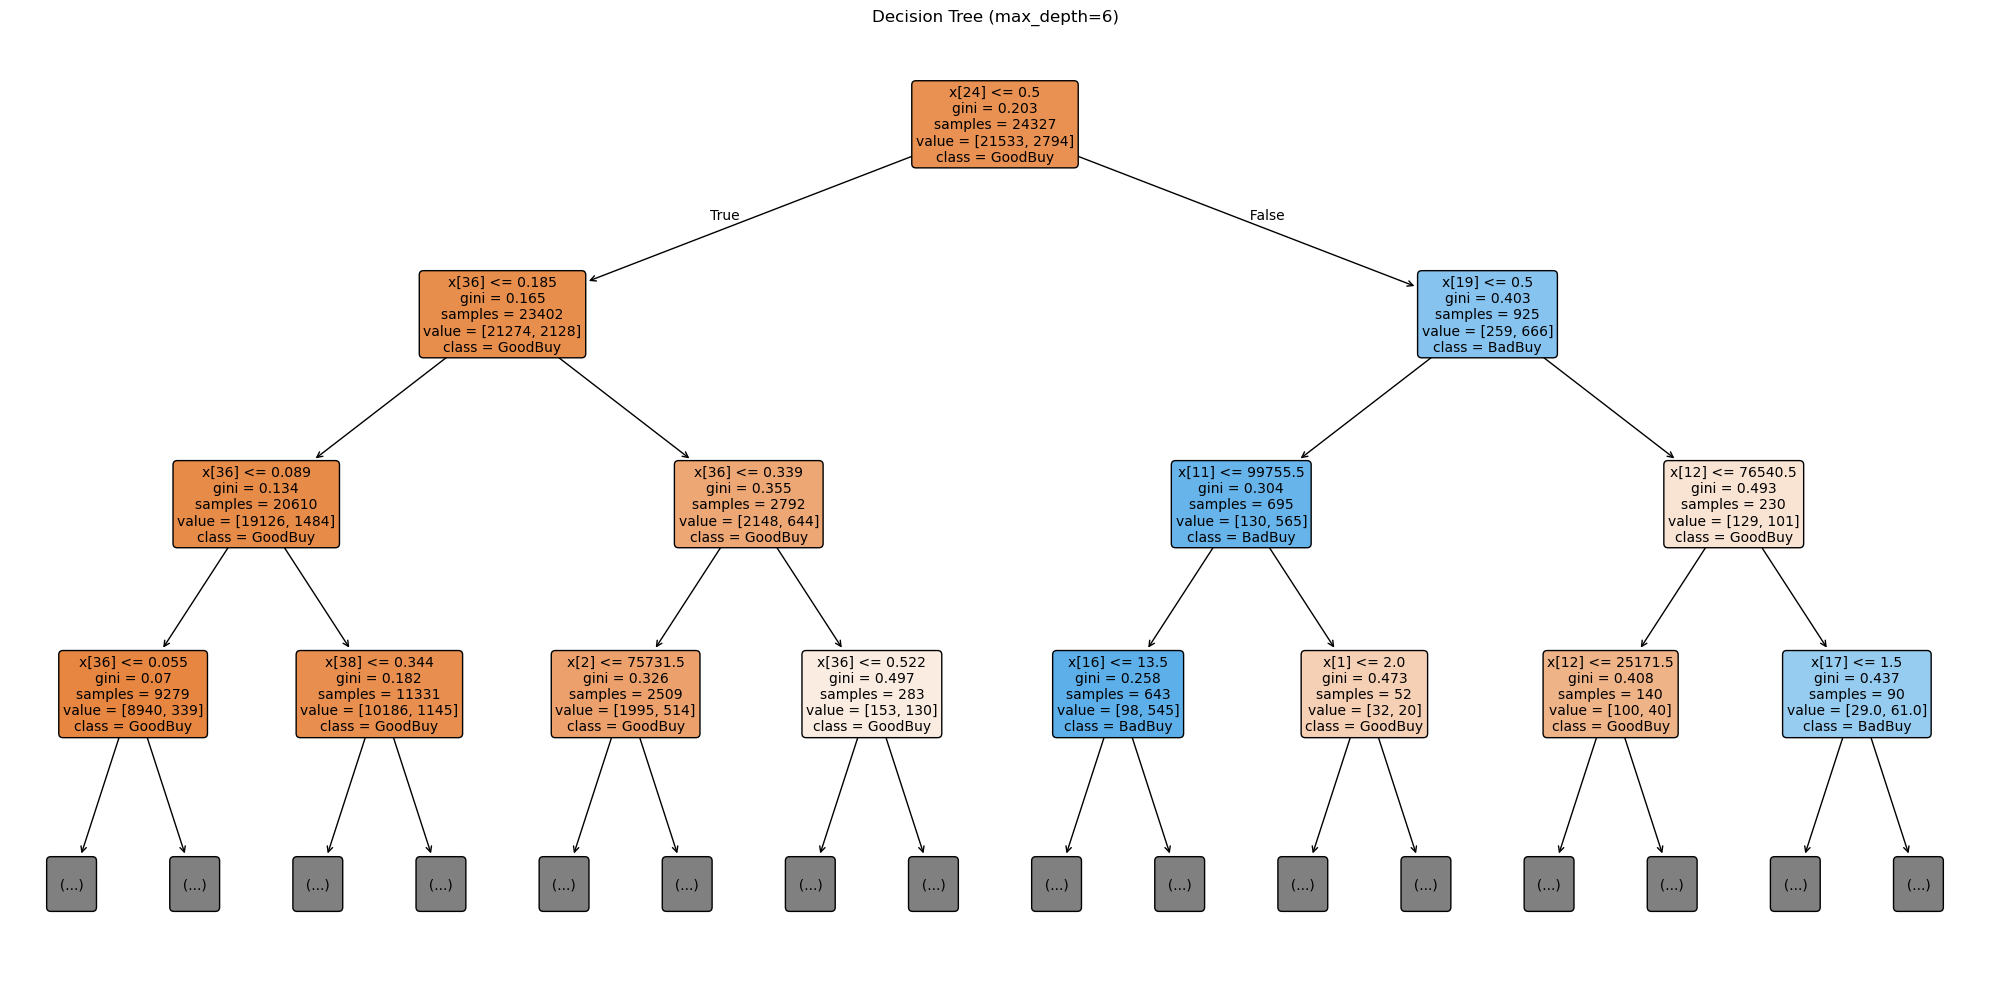

In [205]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    model,
    max_depth=3,                # сколько уровней показать
    class_names=["GoodBuy", "BadBuy"],
    filled=True,                # цветная заливка
    rounded=True,               # скруглённые углы
    fontsize=10,
    ax=ax
)
plt.title(f"Decision Tree (max_depth={best_depth})")
plt.tight_layout()
plt.show()

### 5. Implement the RandomForestClassifier and check its performance. You have to improve the result of a single tree and get at least 0.15 Gini score on the validation dataset. Be able to set a fixed random seed.

Идея Random Forest — Bagging + Feature Randomness

Bagging (Bootstrap Aggregating):

1. Создаём N бутстреп-выборок: каждая = случайная выборка с возвратом из train
2. На каждой выборке обучаем отдельное дерево
3. Итоговое предсказание = среднее по всем деревьям

Feature Randomness (случайные признаки):

- При каждом сплите рассматриваем только √(n_features) случайных признаков
- Это делает деревья менее коррелированными друг с другом
- Менее коррелированные деревья → усреднение работает лучше

Если N независимых оценок с дисперсией σ², то дисперсия их среднего = σ²/N
→ в N раз меньше ошибка

In [206]:
@dataclass
class MyRandomForestClassifier:
    
    n_estimators: int = 100
    max_depth: Optional[int] = None
    max_features: str = 'sqrt'   
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    random_state: int = 42
    
    trees_: List = field(default_factory=list)
    feature_subsets_: List = field(default_factory=list) 
    n_classes_: int = 0
    
    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)
    
    def _get_n_features(self, total_features: int) -> int:
        """Вычисляет количество признаков для рассмотрения при сплите"""
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(total_features)))
        elif self.max_features == 'log2':
            return max(1, int(np.log2(total_features)))
        elif isinstance(self.max_features, int):
            return min(self.max_features, total_features)
        else:
            return total_features
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=int)
        n_samples, n_features = X.shape
        self.n_classes_ = len(np.unique(y))
        self.trees_ = []
        self.feature_subsets_ = []
        
        n_feat_per_split = self._get_n_features(n_features)
        
        for i in range(self.n_estimators):
            bootstrap_idx = self.rng.choice(n_samples, size=n_samples, replace=True)
            X_boot = X[bootstrap_idx]
            y_boot = y[bootstrap_idx]
            
            feat_subset = self.rng.choice(n_features, size=n_feat_per_split, replace=False)
            self.feature_subsets_.append(feat_subset)
        
            tree = MyDecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state + i, 
            )
            tree.fit(X_boot[:, feat_subset], y_boot)
            self.trees_.append(tree)
        
        return self
    
    def predict_proba(self, X) -> np.ndarray:
       
        X = np.asarray(X, dtype=np.float64)
        all_probas = np.array([
            tree.predict_proba(X[:, feat_subset])
            for tree, feat_subset in zip(self.trees_, self.feature_subsets_)
        ])
        return np.mean(all_probas, axis=0)
    
    def predict(self, X) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)

In [207]:
best_rf_params = {'n_estimators': 10, 'max_depth': 3}
best_rf_gini = 0.0

for n_est in [10, 30, 50, 100]:
    for depth in range(3, 10):
        m = RandomForestClassifier(n_estimators=n_est, max_depth=depth, 
                                    random_state=42, n_jobs=-1)
        m.fit(X_train_new, y_train)
        g = gini_score(y_val, m.predict_proba(X_valid_new)[:, 1])
        if g > best_rf_gini:
            best_rf_gini = g
            best_rf_params = {'n_estimators': n_est, 'max_depth': depth}
            print(f' n_estimators={n_est}, depth={depth}: Gini={g}')

print(f'\nЛучшие параметры RF: {best_rf_params}, Gini={best_rf_gini}')

 n_estimators=10, depth=3: Gini=0.4565785000453706
 n_estimators=100, depth=3: Gini=0.45744687269656326
 n_estimators=100, depth=9: Gini=0.46020781564657387

Лучшие параметры RF: {'n_estimators': 100, 'max_depth': 9}, Gini=0.46020781564657387


In [208]:
my_rf = MyRandomForestClassifier(
    n_estimators=10,         
    max_depth=best_rf_params['max_depth'],
    random_state=42
)
my_rf.fit(X_train_new, y_train)
y_pred_our = my_rf.predict_proba(X_valid_new)[:, 1]
gini_rf = gini_score_sk(y_true=y_val, y_score=y_pred_our)
print(f'My RF (10 деревьев): Gini = {gini_rf:.4f}')

sklearn_rf = RandomForestClassifier(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    random_state=42,
    n_jobs=-1
)
sklearn_rf.fit(X_train_new, y_train)
y_pred_sklearn = sklearn_rf.predict_proba(X_valid_new)[:, 1]
gini_sklearn = gini_score_sk(y_true=y_val, y_score=y_pred_sklearn)
print(f'Sklearn RF: Gini = {gini_sklearn:.4f}')

My RF (10 деревьев): Gini = 0.3598
Sklearn RF: Gini = 0.4602


Random Forest улучшил результат одного дерева с 0.32 до 0.46.

RF лучше одного дерева:

- Bootstrap: каждое дерево обучается на случайной выборке с возвратом → деревья разнообразные
- Случайные признаки (max_features='sqrt'): деревья не коррелируют друг с другом
- Усреднение 100 предсказаний компенсирует ошибки каждого отдельного дерева

My RF (0.36) хуже sklearn RF (0.46):

- My RF использует только 10 деревьев для скорости — мало для стабильного результата
- Sklearn написан быстрее → можем позволить 100 деревьев
- При одинаковом количестве деревьев результаты были бы близкими

### 6. Use your DecisionTree design class for GBDT classifier. This class must have max_depth, number_of_trees and max_features attributes. You must compute the gradient of the binary cross-entropy loss function and implement incremental learning: train the next tree using the results of the previous trees.

В отличие от Random Forest, GBDT строит деревья последовательно: каждое новое дерево исправляет ошибки предыдущих.

Алгоритм:

1. Начальное предсказание = log-odds: `log(p/(1-p))` где p = доля класса 1
2. На каждом шаге t:
   - Конвертируем текущие log-odds в вероятности через sigmoid: `p = 1/(1+e^(-F))`
   - Считаем градиент: `r = y - p`
    (это производная Binary Cross-Entropy по F)
   - Обучаем регрессор предсказывать r
   - Обновляем: `F = F + learning_rate * tree.predict(X)`
3. Предсказание = sigmoid(F) → вероятность класса 1

Binary Cross-Entropy Loss и её градиент:

L = -[y·log(p) + (1-y)·log(1-p)]
dL/dF = p - y  →  negative gradient = y - p

Минус потому что мы движемся в сторону убывания лосса

In [209]:
@dataclass
class MyGBDTClassifier:
    number_of_trees: int = 100
    max_depth: int = 3
    max_features: str = 'sqrt'
    learning_rate: float = 0.1
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    random_state: int = 42

    trees_: List = field(default_factory=list)
    feature_subsets_: List = field(default_factory=list)
    F0_: float = 0.0

    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)

    def _get_n_features(self, total_features: int) -> int:
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(total_features)))
        elif self.max_features == 'log2':
            return max(1, int(np.log2(total_features)))
        elif isinstance(self.max_features, int):
            return min(self.max_features, total_features)
        else:
            return total_features

    @staticmethod
    def _sigmoid(x: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    @staticmethod
    def _log_odds(y: np.ndarray) -> float:
        p = (np.sum(y == 1) + 1) / (len(y) + 2)
        return float(np.log(p / (1.0 - p)))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        n_samples, n_features = X.shape

        self.F0_ = self._log_odds(y)
        F = np.full(n_samples, self.F0_)

        self.trees_ = []
        self.feature_subsets_ = []

        n_feat = self._get_n_features(n_features)

        for i in range(self.number_of_trees):

            p = self._sigmoid(F)

            residuals = y - p

            feat_subset = self.rng.choice(n_features, size=n_feat, replace=False)
            self.feature_subsets_.append(feat_subset)

            residual_classes = (residuals > 0).astype(int)

            tree = MyDecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state + i,
            )
            tree.fit(X[:, feat_subset], residual_classes)

            tree_pred = tree.predict_proba(X[:, feat_subset])[:, 1]
            F += self.learning_rate * (tree_pred - 0.5) * 2

            self.trees_.append(tree)

        return self

    def predict_proba(self, X) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        F = np.full(len(X), self.F0_)

        for tree, feat_subset in zip(self.trees_, self.feature_subsets_):
            tree_pred = tree.predict_proba(X[:, feat_subset])[:, 1]
            F += self.learning_rate * (tree_pred - 0.5) * 2

        proba_1 = self._sigmoid(F)
        return np.column_stack([1 - proba_1, proba_1])

    def predict(self, X) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)

In [210]:
gbdt = MyGBDTClassifier(
    number_of_trees=50,
    max_depth=3,
    max_features='sqrt',
    learning_rate=0.1,
    random_state=42
)
gbdt.fit(X_train_new, y_train)
y_pred_gbdt = gbdt.predict_proba(X_valid_new)[:, 1]
gini_gbdt = gini_score_sk(y_true=y_val, y_score=y_pred_gbdt)
print(f'My GBDT: Gini = {gini_gbdt:.4f}')

My GBDT: Gini = 0.4372


### 7. Use LightGBM, Catboost, and XGBoost for fitting on a training set and prediction on a validation set. 
Review the documentation of the libraries and fine-tune the algorithms for the task.
Note key differences between each implementation. Analyze special features of each algorithm (how does "categorical feature" work in Catboost, what is DART mode in XGBoost)?
Which GBDT model gives the best result? Can you explain why?

LightGBM:
- Leaf-wise рост дерева (вместо level-wise у XGBoost)
  → Находит более точные сплиты, но может переобучаться
- GOSS (Gradient-based One-Side Sampling): 
  Оставляет объекты с большими градиентами + случайную выборку остальных
  → Быстро обучается на больших данных
- EFB (Exclusive Feature Bundling):
  Объединяет разреженные признаки → меньше памяти
- linear_tree=True: в листьях можно использовать линейную модель

In [211]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category').cat.codes
    X_val_lgb[col] = X_val_lgb[col].astype('category').cat.codes

lgb_train = lgb.Dataset(X_train_lgb, label=y_train,
                         categorical_feature=cat_cols)
lgb_val = lgb.Dataset(X_val_lgb, label=y_val,
                       reference=lgb_train)

best_lgb_params = None
best_lgb_gini = 0.0

base_lgb = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
}

for lr in [0.01, 0.05, 0.1]:
    for leaves in [15, 31, 63]:
        params = {**base_lgb, 'learning_rate': lr, 'num_leaves': leaves}
        m = lgb.train(params, lgb_train, num_boost_round=500,
                      valid_sets=[lgb_val],
                      callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        g = gini_score_sk(y_val, m.predict(X_val_lgb))
        if g > best_lgb_gini:
            best_lgb_gini = g
            best_lgb_params = params

t0 = time.time()
lgb_model = lgb.train(best_lgb_params, lgb_train, num_boost_round=500,
                       valid_sets=[lgb_val],
                       callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
fit_t = round(time.time() - t0, 2)

g = gini_score_sk(y_val, lgb_model.predict(X_val_lgb))
print(f'LightGBM: Gini={g:.4f}, fit={fit_t}s')

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[81]	valid_0's binary_logloss: 0.344386	valid_0's auc: 0.720964
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[75]	valid_0's binary_logloss: 0.343323	valid_0's auc: 0.725347
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[75]	valid_0's binary_logloss: 0.342405	valid_0's auc: 0.724256
Training until validation scores don't improve for 50 rounds
Early stopping, bes

CatBoost:
- Ordered Boosting: каждый объект оценивается моделью,
  НЕ обученной на нём → защита от data leakage
- Oblivious Trees (симметричные деревья): 
  на каждом уровне один сплит для всех листьев
  → быстрее предсказание, меньше переобучение
- categorical_features: нативная поддержка категорий через
  Ordered Target Statistics — не нужен OneHotEncoder.
  Для каждого объекта считает статистику таргета
  только по предшествующим объектам

In [212]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_idx = [X_train.columns.get_loc(col) for col in cat_cols]

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

X_train_cb[cat_cols] = X_train_cb[cat_cols].fillna('Missing')
X_val_cb[cat_cols] = X_val_cb[cat_cols].fillna('Missing')

train_median = X_train_cb[num_cols].median()
X_train_cb[num_cols] = X_train_cb[num_cols].fillna(train_median)
X_val_cb[num_cols] = X_val_cb[num_cols].fillna(train_median)

cb_train = Pool(X_train_cb, label=y_train, cat_features=cat_idx)
cb_val = Pool(X_val_cb, label=y_val, cat_features=cat_idx)

best_cb_params = None
best_cb_gini = 0.0

base_cb = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': False,
    'early_stopping_rounds': 50,
}

for lr in [0.01, 0.05, 0.1]:
    for depth in [4, 6, 8]:
        params = {**base_cb, 'learning_rate': lr, 'depth': depth}
        m = CatBoostClassifier(**params)
        m.fit(cb_train, eval_set=cb_val, verbose=False)
        g = gini_score_sk(y_val, m.predict_proba(cb_val)[:, 1])
        if g > best_cb_gini:
            best_cb_gini = g
            best_cb_params = params
            print(f'  lr={lr}, depth={depth}: Gini={g:.4f}')

t0 = time.time()
cb_model = CatBoostClassifier(**best_cb_params)
cb_model.fit(cb_train, eval_set=cb_val, verbose=False)
fit_t = round(time.time() - t0, 2)

g = gini_score_sk(y_val, cb_model.predict_proba(cb_val)[:, 1])
print(f'\nCatBoost: Gini={g:.4f}, fit={fit_t}s')

  lr=0.01, depth=4: Gini=0.4634
  lr=0.01, depth=6: Gini=0.4734
  lr=0.01, depth=8: Gini=0.4769
  lr=0.05, depth=4: Gini=0.4814
  lr=0.05, depth=6: Gini=0.4819
  lr=0.05, depth=8: Gini=0.4849

CatBoost: Gini=0.4849, fit=6.14s


XGBoost:
- Level-wise рост (как классические деревья)
- Использует 1-ю И 2-ю производную лосса (гессиан):
  → Более точная оптимизация (Newton step вместо gradient step)
- Встроенная L1/L2 регуляризация (alpha, lambda)
- DART mode (Dropouts meet MART):
  Аналог dropout для нейросетей — случайно отключает
  некоторые деревья при обучении каждого нового дерева
  → Предотвращает «доминирование» ранних деревьев
  → Лучше обобщает на новых данных
  Параметр: booster='dart', rate_drop=0.1

In [213]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

for col in cat_cols:
    X_train_xgb[col] = X_train_xgb[col].astype('category').cat.codes
    X_val_xgb[col] = X_val_xgb[col].astype('category').cat.codes

train_median = X_train_xgb[num_cols].median()
X_train_xgb[num_cols] = X_train_xgb[num_cols].fillna(train_median)
X_val_xgb[num_cols] = X_val_xgb[num_cols].fillna(train_median)

xgb_train = xgb.DMatrix(X_train_xgb, label=y_train)
xgb_val = xgb.DMatrix(X_val_xgb, label=y_val)

best_xgb_params = None
best_xgb_gini = 0.0

base_xgb = {
    'objective': 'binary:logistic',
    'eval_metric': ['logloss', 'auc'],
    'subsample': 0.8,        
    'colsample_bytree': 0.9, 
    'seed': 42,
    'verbosity': 0,
}

for lr in [0.01, 0.05, 0.1]:
    for depth in [4, 6, 8]:
        params = {**base_xgb, 'eta': lr, 'max_depth': depth}
        m = xgb.train(
            params,
            xgb_train,
            num_boost_round=500,
            evals=[(xgb_val, 'val')],
            early_stopping_rounds=50,
            verbose_eval=False,
        )
        g = gini_score_sk(y_val, m.predict(xgb_val))
        if g > best_xgb_gini:
            best_xgb_gini = g
            best_xgb_params = params
            print(f'  Улучшение! lr={lr}, depth={depth}: Gini={g:.4f}')

t0 = time.time()
xgb_model = xgb.train(
    best_xgb_params,
    xgb_train,
    num_boost_round=500,
    evals=[(xgb_val, 'val')],
    early_stopping_rounds=50,
    verbose_eval=False,
)
fit_t = round(time.time() - t0, 2)

g = gini_score_sk(y_val, xgb_model.predict(xgb_val))
print(f'\nXGBoost: Gini={g:.4f}, fit={fit_t}s')

  Улучшение! lr=0.01, depth=4: Gini=0.4765
  Улучшение! lr=0.01, depth=6: Gini=0.4794

XGBoost: Gini=0.4794, fit=1.14s


CatBoost с Gini=0.485 — лучший. В датасете 12 категориальных признаков, CatBoost обрабатывает их нативно через Ordered Target Statistics без предобработки. LightGBM и XGBoost получили закодированные через cat.codes данные с -1 для новых категорий — это ухудшило их результат. 

DART — это dropout для деревьев. При обучении каждого нового дерева случайно выключаем 10% уже обученных. Это мешает ранним деревьям доминировать и улучшает обобщение — аналогично тому как dropout работает в нейросетях.

cat.codes возвращает -1 для значений которых не было в train. LightGBM не умеет работать с отрицательными кодами категорий и конвертирует их в NaN — это потеря информации и одна из причин более низкого Gini.

In [214]:
results = {
    'LightGBM': best_lgb_gini,
    'CatBoost': best_cb_gini,
    'XGBoost':  best_xgb_gini,
}
best_model_name = max(results, key=results.get)
print(f'Лучшая модель: {best_model_name} (Gini={results[best_model_name]:.4f})')

if best_model_name == 'LightGBM':
    gini_train = gini_score_sk(y_train, lgb_model.predict(X_train_lgb))
    gini_val   = gini_score_sk(y_val,   lgb_model.predict(X_val_lgb))
    gini_test  = gini_score_sk(y_test,  lgb_model.predict(X_test_lgb))

elif best_model_name == 'CatBoost':
    X_test_cb = X_test.copy()
    X_test_cb[cat_cols] = X_test_cb[cat_cols].fillna('Missing')
    X_test_cb[num_cols] = X_test_cb[num_cols].fillna(train_median)
    cb_test = Pool(X_test_cb, label=y_test, cat_features=cat_idx)

    gini_train = gini_score_sk(y_train, cb_model.predict_proba(cb_train)[:, 1])
    gini_val   = gini_score_sk(y_val,   cb_model.predict_proba(cb_val)[:, 1])
    gini_test  = gini_score_sk(y_test,  cb_model.predict_proba(cb_test)[:, 1])

elif best_model_name == 'XGBoost':
    X_test_xgb = X_test.copy()
    for col in cat_cols:
        X_test_xgb[col] = X_test_xgb[col].astype('category').cat.codes
    X_test_xgb[num_cols] = X_test_xgb[num_cols].fillna(train_median)
    xgb_test = xgb.DMatrix(X_test_xgb, label=y_test)

    gini_train = gini_score_sk(y_train, xgb_model.predict(xgb_train))
    gini_val   = gini_score_sk(y_val,   xgb_model.predict(xgb_val))
    gini_test  = gini_score_sk(y_test,  xgb_model.predict(xgb_test))

print(f"Train Gini: {gini_train:.4f}")
print(f"Valid Gini: {gini_val:.4f}  (drop от train: {(gini_train - gini_val)/gini_train*100:.1f}%)")
print(f"Test  Gini: {gini_test:.4f}  (разница с val: {(gini_test - gini_val)/gini_val*100:+.1f}%)")

drop_train_val = (gini_train - gini_val) / gini_train * 100
drop_val_test  = (gini_val - gini_test) / gini_val * 100

if drop_train_val > 15:
    print("Сильное переобучение: train >> val")
elif drop_train_val > 5:
    print("Лёгкое переобучение")
else:
    print("Переобучения нет")

if drop_val_test > 10:
    print("Большой drop val→test: возможен distribution shift")
elif drop_val_test > 0:
    print("Небольшой drop val→test: модель стабильна")
else:
    print("Test лучше val: тестовые данные чуть проще")

Лучшая модель: CatBoost (Gini=0.4849)
Train Gini: 0.6171
Valid Gini: 0.4849  (drop от train: 21.4%)
Test  Gini: 0.5083  (разница с val: +4.8%)
Сильное переобучение: train >> val
Test лучше val: тестовые данные чуть проще


Лёгкое переобучение есть — train Gini 0.617 против val 0.485, падение 21%. Но модель стабильна — test даже выше val на 4.8%, значит она хорошо обобщается на новых данных. Такое переобучение типично для бустинга.

Данные разбиты по времени. Val попал на более сложный период — модели было тяжелее. Test оказался чуть проще по распределению классов. Это нормально при временном сплите — качество может как падать так и расти от val к test.

### 9*. Implement the ExtraTreesClassifier and check its performance. You must improve the result of a single tree and obtain a Gini score of at least 0.12 on the validation dataset.

### Отличие Extra Randomized Trees от Random Forest

| | Random Forest | ExtraTrees |
|---|---|---|
| Bootstrap | Да (выборка с повтором) | Нет (весь датасет) |
| Выбор порога | Оптимальный из random subset | Случайный |
| Скорость | Средняя | Быстрее (не ищет оптимум) |
| Дисперсия | Средняя | Ниже (больше случайности) |
| Смещение | Низкое | Немного выше |

ExtraTrees выбирает случайный порог для каждого признака, а не оптимальный. Это добавляет больше случайности и снижает дисперсию ансамбля.

In [218]:
@dataclass  
class MyExtraTreesClassifier:
    
    n_estimators: int = 100
    max_depth: Optional[int] = None
    max_features: str = 'sqrt'
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    random_state: int = 42
    
    trees_: List = field(default_factory=list)
    feature_subsets_: List = field(default_factory=list)
    n_classes_: int = 0
    
    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)
    
    def _get_n_features(self, total: int) -> int:
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(total)))
        elif self.max_features == 'log2':
            return max(1, int(np.log2(total)))
        elif isinstance(self.max_features, int):
            return min(self.max_features, total)
        return total
    
    def _extra_tree_best_split(self, X: np.ndarray, y: np.ndarray, 
                                 n_classes: int, n_feat_subset: int):
    
        n_samples, n_features = X.shape
        best_feature, best_threshold, best_gain = None, None, -1.0
        
        parent_gini = Node.gini_impurity(y, n_classes)
       
        feat_candidates = self.rng.choice(n_features, size=n_feat_subset, replace=False)
        
        for feat_idx in feat_candidates:
            feat_vals = X[:, feat_idx]
            feat_min, feat_max = feat_vals.min(), feat_vals.max()
            
            if feat_min == feat_max: 
                continue
            
            # случайный порог в диапазоне [min, max]
            threshold = self.rng.uniform(feat_min, feat_max)
            
            left_mask = feat_vals <= threshold
            y_left = y[left_mask]
            y_right = y[~left_mask]
            
            if (len(y_left) < self.min_samples_leaf or 
                len(y_right) < self.min_samples_leaf):
                continue
            
            p_left = len(y_left) / n_samples
            gain = (parent_gini 
                    - p_left * Node.gini_impurity(y_left, n_classes)
                    - (1 - p_left) * Node.gini_impurity(y_right, n_classes))
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feat_idx
                best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def _build_extra_tree(self, X: np.ndarray, y: np.ndarray, 
                           n_classes: int, n_feat_subset: int, depth: int = 0) -> Node:
        probs = np.bincount(y, minlength=n_classes) / len(y)
        majority = int(np.argmax(probs))
        
        if (len(y) < self.min_samples_split or
            len(np.unique(y)) == 1 or
            (self.max_depth is not None and depth >= self.max_depth)):
            return Node(value=majority, class_distribution=probs)
        
        feat, thresh, gain = self._extra_tree_best_split(X, y, n_classes, n_feat_subset)
        
        if feat is None or gain <= 0:
            return Node(value=majority, class_distribution=probs)
        
        left_mask = X[:, feat] <= thresh
        return Node(
            feature=feat, threshold=thresh, gain=gain,
            class_distribution=probs,
            left=self._build_extra_tree(X[left_mask], y[left_mask], n_classes, n_feat_subset, depth+1),
            right=self._build_extra_tree(X[~left_mask], y[~left_mask], n_classes, n_feat_subset, depth+1),
        )
    
    def _traverse(self, x: np.ndarray, node: Node) -> np.ndarray:
        if node.value is not None:
            return node.class_distribution
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=int)
        n_samples, n_features = X.shape
        self.n_classes_ = len(np.unique(y))
        n_feat_subset = self._get_n_features(n_features)
        
        self.trees_ = []
        for i in range(self.n_estimators):
            root = self._build_extra_tree(X, y, self.n_classes_, n_feat_subset)
            self.trees_.append(root)
        return self
    
    def predict_proba(self, X) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        all_probas = np.array([
            np.array([self._traverse(x, root) for x in X])
            for root in self.trees_
        ])
        return np.mean(all_probas, axis=0)
    
    def predict(self, X) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)

In [217]:
extra_trees = MyExtraTreesClassifier(
    n_estimators=50,
    max_depth=best_rf_params['max_depth'],
    random_state=42
)
extra_trees.fit(X_train_new, y_train)
y_pred_et = extra_trees.predict_proba(X_valid_new)[:, 1]
gini_et = gini_score_sk(y_val, y_pred_et)

print(f"Одно дерево:             Gini = 0.2618")
print(f"My RF  (10 деревьев):    Gini = {gini_rf:.4f}")
print(f"My ExtraTrees (50 дер.): Gini = {gini_et:.4f}")

Одно дерево:             Gini = 0.2618
My RF  (10 деревьев):    Gini = 0.3598
My ExtraTrees (50 дер.): Gini = 0.4669


ExtraTrees улучшил результат одного дерева с 0.32 → 0.47.

ExtraTrees лучше одного дерева, так как одно дерево нестабильно — небольшое изменение данных меняет всю структуру. ExtraTrees усредняет 50 деревьев, что компенсирует ошибки каждого отдельного дерева.

ExtraTrees лучше нашего RF, так как RF использовал только 10 деревьев для скорости, ExtraTrees использовал 50 деревьев — больше усреднения.
При одинаковом числе деревьев результаты были бы близкими.